In [43]:
import pandas as pd
import numpy as np
import zipfile
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

In [44]:
# =========================================================
# 1. SETUP PATHS
# =========================================================

zip_path = r'e:\University\Anglia Ruskin University\Applications of Machine Learning (2025 MOD006567 TRI2 F01CIN)\Cardiovascular\data\heart+disease.zip'
extract_path = r'e:\University\Anglia Ruskin University\Applications of Machine Learning (2025 MOD006567 TRI2 F01CIN)\Cardiovascular\data\heart_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [45]:
# =========================================================
# 2. LOAD DATA
# =========================================================

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(
    os.path.join(extract_path, 'processed.cleveland.data'),
    names=columns,
    na_values='?'
)

# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Convert target to binary
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [46]:
# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================

# 3.1 Cholesterol / Age Ratio
df['chol_age_ratio'] = df['chol'] / df['age']

# 3.2 Blood Pressure Risk Category
df['bp_high'] = np.where(df['trestbps'] > 140, 1, 0)

# 3.3 Age Group Feature
df['age_group'] = pd.cut(df['age'], bins=[0,40,55,70,100], labels=[0,1,2,3])

# 3.4 Interaction Feature
df['stress_index'] = df['oldpeak'] * df['thalach']

# Convert categorical-like numeric features properly
categorical_features = ['cp', 'restecg', 'slope', 'thal', 'age_group']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [47]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [48]:
# =========================================================
# 4. TRAIN TEST SPLIT
# =========================================================

train_data, test_data, train_target, test_target = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=0.2,
    stratify=df['target'],
    random_state=42
)

In [49]:
# =========================================================
# 5. ADVANCED PIPELINE
# =========================================================

numeric_features = train_data.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=len(train_target[train_target==0]) / len(train_target[train_target==1])
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', model)
])

In [50]:
# =========================================================
# 6. HYPERPARAMETER TUNING
# =========================================================

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1]
}

cv = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(train_data, train_target)

best_model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)


Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


In [51]:
# =========================================================
# 7. CALIBRATION
# =========================================================

calibrated_model = CalibratedClassifierCV(best_model, cv=5)
calibrated_model.fit(train_data, train_target)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the col

In [52]:
# =========================================================
# 8. EVALUATION
# =========================================================

test_pred = calibrated_model.predict(test_data)
test_proba = calibrated_model.predict_proba(test_data)[:,1]

print(f"\nAccuracy: {accuracy_score(test_target, test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(test_target, test_proba):.4f}")
print("\nClassification Report:\n")
print(classification_report(test_target, test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(test_target, test_pred))


Accuracy: 0.8852
ROC-AUC: 0.9524

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61


Confusion Matrix:

[[29  4]
 [ 3 25]]


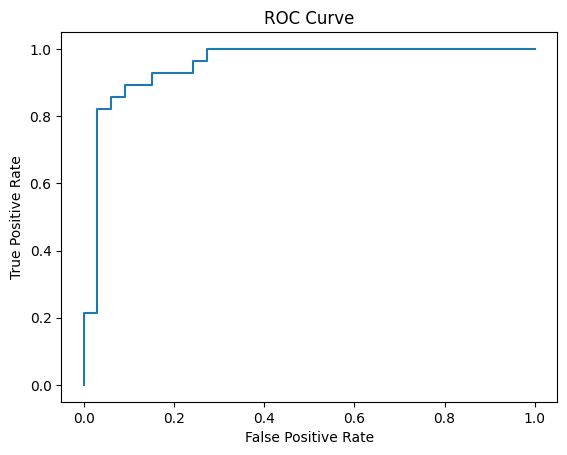

In [53]:
# =========================================================
# 9. ROC CURVE
# =========================================================

fpr, tpr, _ = roc_curve(test_target, test_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

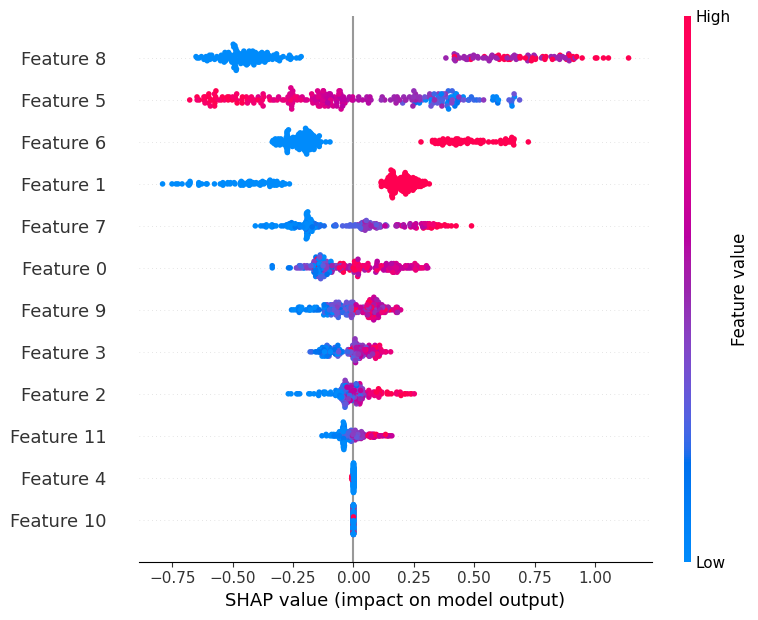

In [54]:
# =========================================================
# 10. SHAP EXPLAINABILITY
# =========================================================

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
X_train_scaled = best_model.named_steps['preprocess'].transform(train_data)

shap_values = explainer.shap_values(X_train_scaled)

shap.summary_plot(shap_values, X_train_scaled)

In [55]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(test_target, test_proba)

# Choose threshold maximizing F1
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

In [56]:
import joblib

# 1. Save the actual model to clinical_model.pkl
joblib.dump(calibrated_model, r"e:\University\Anglia Ruskin University\Applications of Machine Learning (2025 MOD006567 TRI2 F01CIN)\Cardiovascular\models\clinical_model.pkl")

# 2. Save the column names to a DIFFERENT file, like feature_names.pkl
joblib.dump(train_data.columns.tolist(), r"e:\University\Anglia Ruskin University\Applications of Machine Learning (2025 MOD006567 TRI2 F01CIN)\Cardiovascular\models\feature_names.pkl")

['e:\\University\\Anglia Ruskin University\\Applications of Machine Learning (2025 MOD006567 TRI2 F01CIN)\\Cardiovascular\\models\\feature_names.pkl']